# Environments Setup

In [ ]:
import gymnasium as gym
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.monitor import load_results
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
%matplotlib inline


In [ ]:
# Reward Shaping environment
class LunarLanderRewardShaping(gym.RewardWrapper):
    def __init__(self, env, penalty_weight=0.5):
        super().__init__(env)
        self.penalty_weight = penalty_weight

    def reward(self, reward):
        # Fetch the current state vector from the unwrapped env
        # State vector indices: 0 = x (horizontal position), 1 = y (vertical position)
        state = self.env.unwrapped.state
        x_pos = state[0]
        
        # Calculate a penalty proportional to the horizontal distance from the center pad (x=0)
        distance_penalty = -abs(x_pos) * self.penalty_weight
        
        return reward + distance_penalty

# General Environment generator
def make_lunar_env(env_type="baseline", render_mode=None):
    """
    Types: 'baseline', 'wind_only', 'shaping_only', 'wind_and_shaping'
    """
    # Configure native wind parameters
    enable_wind = "wind" in env_type
    
    # Initialize native environment
    env = gym.make(
        "LunarLander-v3", 
        enable_wind=enable_wind, 
        wind_power=15.0,       
        turbulence_power=1.5,   # Standard recommended turbulence magnitude
        render_mode=render_mode
    )
    
    # Inject reward shaping if specified
    if "shaping" in env_type:
        env = LunarLanderRewardShaping(env, penalty_weight=0.75)

        
    return env

# PPO Hyperparameter Tuning on Baseline Environment

In [ ]:
import optuna
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

def objective(trial):
    # Establishing the baseline environment
    env = gym.make("LunarLander-v3")
    
    # Hyperparameter search space
    hyperparameters = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
        "n_steps": trial.suggest_categorical("n_steps", [512, 1024, 2048, 4096]),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128, 256]),
        "n_epochs": trial.suggest_int("n_epochs", 3, 20),
        "gamma": trial.suggest_float("gamma", 0.98, 0.999),
        "gae_lambda": trial.suggest_float("gae_lambda", 0.9, 1.0),
        "clip_range": trial.suggest_float("clip_range", 0.1, 0.4),
        "ent_coef": trial.suggest_float("ent_coef", 1e-8, 1e-2, log=True),
    }
    
    model = PPO(
        "MlpPolicy", 
        env, 
        verbose=0, 
        seed=42,
        **hyperparameters
    )
    
    try:
        # Run 100,000 steps per trial to show performance efficiency
        model.learn(total_timesteps=100000)
        mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=10)
    except Exception:
        return -float("inf")
    finally:
        env.close()
        
    return mean_reward


# Starting Hyperparameter Tuning
study = optuna.create_study(direction="maximize")
print("Starting Hyperparameter Tuning Optimization for PPO...")
study.optimize(objective, n_trials=20)
    
print("\n Tuning Complete")
print(f"Best Target Mean Reward: {study.best_value}")
print("Best Hyperparameters configuration found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-23 15:53:23,454] A new study created in memory with name: no-name-678854e3-fe7a-4029-a543-35c2fb1c544c

Starting Hyperparameter Tuning Optimization for PPO...


[I 2026-06-23 15:54:09,785] Trial 0 finished with value: -314.110271714069 and parameters: {'learning_rate': 
0.0006057822610304369, 'n_steps': 2048, 'batch_size': 64, 'n_epochs': 3, 'gamma': 0.9815034047391822, 'gae_lambda':
0.9095453496361328, 'clip_range': 0.12795068207743843, 'ent_coef': 0.005575486694825285}. Best is trial 0 with 
value: -314.110271714069.

[I 2026-06-23 15:55:02,102] Trial 1 finished with value: -1086.9885612700134 and parameters: {'learning_rate': 
1.669563990351239e-05, 'n_steps': 1024, 'batch_size': 256, 'n_epochs': 13, 'gamma': 0.9964680854945996, 
'gae_lambda': 0.9086108766999692, 'clip_range': 0.11949584822323642, 'ent_coef': 8.881570956956819e-05}. Best is 
trial 0 with value: -314.110271714069.

[I 2026-06-23 15:55:56,352] Trial 2 finished with value: -348.8856173329521 and parameters: {'learning_rate': 
5.642162273720336e-05, 'n_steps': 2048, 'batch_size': 256, 'n_epochs': 18, 'gamma': 0.9928751554094317, 
'gae_lambda': 0.9936717018287163, 'clip_range': 0.3298504645378738, 'ent_coef': 1.1479325519878243e-08}. Best is 
trial 0 with value: -314.110271714069.

...

[I 2026-06-23 16:14:34,237] Trial 16 finished with value: -57.23089794517766 and parameters: {'learning_rate': 
0.0006183964765148428, 'n_steps': 2048, 'batch_size': 128, 'n_epochs': 13, 'gamma': 0.9842616139662068, 
'gae_lambda': 0.9536793722315459, 'clip_range': 0.16918635589856074, 'ent_coef': 0.0014254184914532185}. Best is 
trial 10 with value: 240.27824479696747.

[I 2026-06-23 16:15:24,978] Trial 17 finished with value: -615.2793363577454 and parameters: {'learning_rate': 
9.9491625952733e-05, 'n_steps': 2048, 'batch_size': 256, 'n_epochs': 14, 'gamma': 0.9905834670611744, 'gae_lambda':
0.9784200519133919, 'clip_range': 0.2935345993858407, 'ent_coef': 0.00012501593560320805}. Best is trial 10 with 
value: 240.27824479696747.

[I 2026-06-23 16:17:27,461] Trial 18 finished with value: 131.16468923355225 and parameters: {'learning_rate': 
0.0004518515697460785, 'n_steps': 512, 'batch_size': 64, 'n_epochs': 18, 'gamma': 0.9847743866267694, 'gae_lambda':
0.9287432669506861, 'clip_range': 0.19770918272977944, 'ent_coef': 1.7652164232163218e-05}. Best is trial 10 with 
value: 240.27824479696747.

[I 2026-06-23 16:18:57,201] Trial 19 finished with value: -1710.8913313539117 and parameters: {'learning_rate': 
4.721286572293503e-05, 'n_steps': 512, 'batch_size': 64, 'n_epochs': 11, 'gamma': 0.9888058901066403, 'gae_lambda':
0.9230285891938363, 'clip_range': 0.20057989385658867, 'ent_coef': 1.8937384348560535e-05}. Best is trial 10 with 
value: 240.27824479696747.


--- Tuning Complete ---
Best Target Mean Reward: 240.27824479696747
Best Hyperparameters configuration found:
  learning_rate: 0.0009355568054823297
  n_steps: 2048
  batch_size: 128
  n_epochs: 20
  gamma: 0.9866241116611858
  gae_lambda: 0.9420083608001165
  clip_range: 0.20571667898817245
  ent_coef: 0.0005444750490770728


In [7]:
SEEDS = [42, 84, 146, 1447, 2026]

## Multi-Seed training on base environment

In [ ]:
import os
from stable_baselines3.common.callbacks import EvalCallback

# Using best hyperparameters configuration
BEST_PPO_PARAMS = {
    "learning_rate": 0.0009355568,
    "n_steps": 2048,
    "batch_size": 128,
    "n_epochs": 20,
    "gamma": 0.9866241116611858,
    "gae_lambda": 0.9420083608001165,
    "clip_range": 0.20571667898817245,
    "ent_coef": 0.0005444750490770728,
}

SEEDS = [42, 84, 146, 1447, 2026]
TOTAL_TIMESTEPS = 1000000  


base_log_dir = "baseline_monitor_logs"
os.makedirs(base_log_dir, exist_ok=True)

print("Starting 5-Seed training for PPO...")

for seed in SEEDS:
    print(f"  Running Seed {seed}...")

    # Creating training environment and evaluation environment to choose the best model based on evaluation performance
    train_env = gym.make("LunarLander-v3")
    eval_env = gym.make("LunarLander-v3")
    
    save_dir = f"./best_models/ppo_baseline_seed_{seed}/"
    os.makedirs(save_dir, exist_ok=True)

    # Creating the evaluation callback
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=save_dir,
        log_path=save_dir,
        eval_freq=10000,         # Test the agent every 10,000 frames
        deterministic=True,     
        render=False
    )

    
    seed_log_path = os.path.join(base_log_dir, f"seed_{seed}")
    os.makedirs(seed_log_path, exist_ok=True)
    env = Monitor(train_env, filename=os.path.join(seed_log_path, "monitor.csv"))
    
    model = PPO(
        "MlpPolicy",
        env,
        verbose=0,
        seed=seed,
        **BEST_PPO_PARAMS
    )
    
    model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True, callback=eval_callback)
    print(f"Training finished for Seed {seed}. Best model saved to {save_dir}best_model.zip")

    env.close()
    eval_env.close()
    
print("\nTraining complete. All seed log metrics have been successfully exported.")

Starting 5-Seed Baseline Benchmark for PPO...
  -> Running Seed 42...


d:\Queen's\Reinforcement Learning\Project\rlenv\Lib\site-packages\stable_baselines3\common\evaluation.py:71: 
UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting 
modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first
with ``Monitor`` wrapper.
  warnings.warn(

Eval num_timesteps=10000, episode_reward=-496.86 +/- 228.10

Episode length: 169.00 +/- 59.32

New best mean reward!

...

Eval num_timesteps=990000, episode_reward=220.35 +/- 43.44

Episode length: 388.60 +/- 309.52

Eval num_timesteps=1000000, episode_reward=239.78 +/- 24.20

Episode length: 252.80 +/- 58.68

Training finished for Seed 2026. Best model saved to ./best_models/ppo_baseline_seed_2026/best_model.zip

Training complete! All seed log metrics have been successfully exported.


### Plotting learning curve

Performance chart saved to 'ppo_baseline_curve.png'


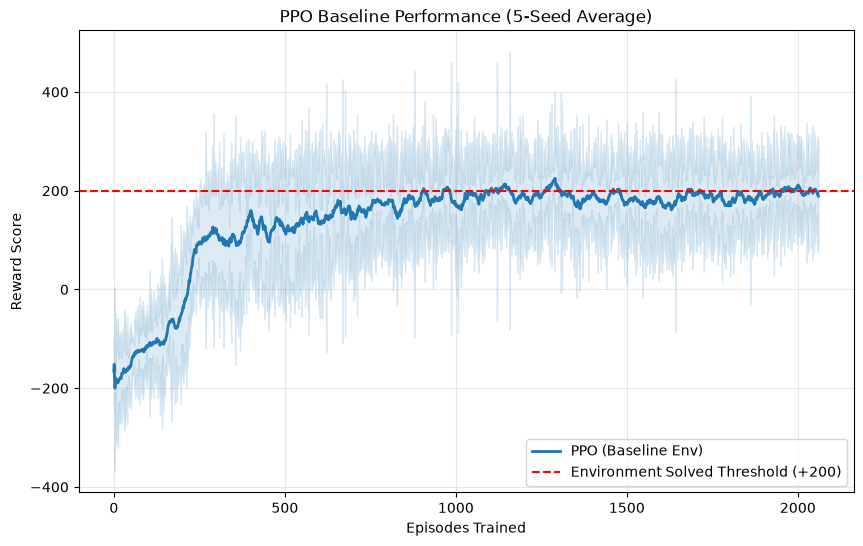

In [ ]:
SEEDS = [42, 84, 146, 1447, 2026]
LOG_DIR = "baseline_monitor_logs"


plt.figure(figsize=(10, 6))
all_seed_rewards = []
    
for seed in SEEDS:
    seed_path = os.path.join(LOG_DIR, f"seed_{seed}")
    try:
        df = load_results(seed_path)
        all_seed_rewards.append(df['r'].values)
    except Exception:
        print(f"Couldn't read log data for seed {seed}")
        continue

if not all_seed_rewards:
    print("No baseline data logs found to plot.")

# Normalizing lengths across runs
min_len = min(len(run) for run in all_seed_rewards)
truncated_runs = [run[:min_len] for run in all_seed_rewards]
    
mean_rewards = np.mean(truncated_runs, axis=0)
std_rewards = np.std(truncated_runs, axis=0)
    
# Smoothing local noise using a 20-episode rolling window
smoothed_mean = pd.Series(mean_rewards).rolling(window=20, min_periods=1).mean()
episodes = np.arange(len(smoothed_mean))
    
# Plotting performance curve and variance shading
plt.plot(episodes, smoothed_mean, color="#1f77b4", linewidth=2, label="PPO (Baseline Env)")
plt.fill_between(episodes, smoothed_mean - std_rewards, smoothed_mean + std_rewards, color="#1f77b4", alpha=0.15)
    
plt.axhline(y=200, color='r', linestyle='--', label='Environment Solved Threshold (+200)')
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("PPO Baseline Performance (5-Seed Average)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
    
output_image = "ppo_baseline_curve.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Performance chart saved to '{output_image}'")
plt.show()


## Testing PPO base environment

 Starting 5-Seed evaluation ...

 Seed 42 raw metrics:
Mean Reward: 184.02
Success Rate: 81.0%
Crash Rate: 11.0%

 Seed 84 raw metrics:
Mean Reward: 155.43
Success Rate: 76.0%
Crash Rate: 18.0%

 Seed 146 raw metrics:
Mean Reward: 230.33
Success Rate: 87.0%
Crash Rate: 5.0%

 Seed 1447 raw metrics:
Mean Reward: 177.30
Success Rate: 75.0%
Crash Rate: 17.0%

 Seed 2026 raw metrics:
Mean Reward: 260.39
Success Rate: 96.0%
Crash Rate: 3.0%

 Final 5-seed metrics averages(PPO - Baseline):
Overall Mean Reward: 201.49 +/- 38.24
Overall Success Rate: 83.0%
Overall Crash Rate: 10.8%
Plotting testing distribution plot...
Testing visualization saved as 'ppo_baseline_testing_distribution.png'


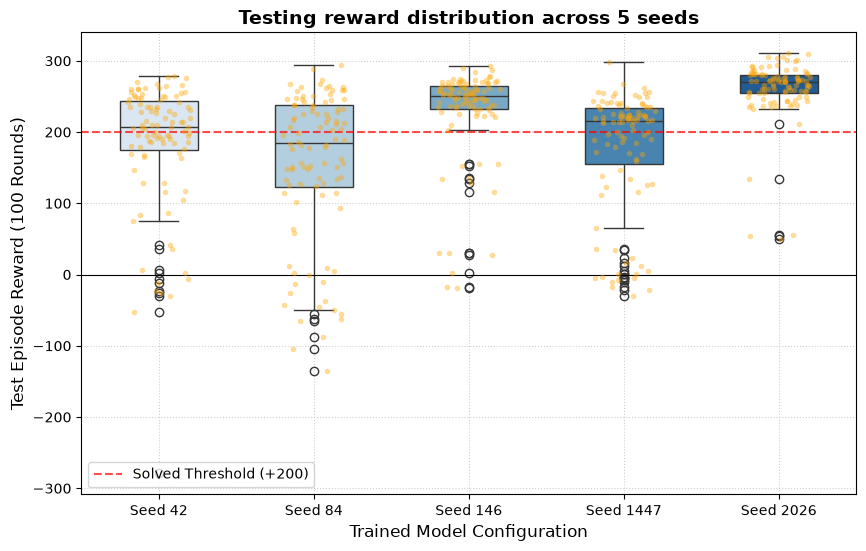

In [25]:
import seaborn as sns

NUM_EVAL_EPISODES = 100

all_seed_mean_rewards = []
all_seed_success_rates = []
all_seed_crash_rates = []

# Storing all 100 raw rewards for every single seed for plotting
all_test_rewards_data = {}

env = gym.make("LunarLander-v3")

print(" Starting 5-Seed evaluation ...\n")

for seed in SEEDS:
    model_path = f"./best_models/ppo_baseline_seed_{seed}/best_model.zip"
    model = PPO.load(model_path, env=env)
    
    seed_rewards = []
    successes = 0
    crashes = 0
    
    for ep in range(NUM_EVAL_EPISODES):
        obs, _ = env.reset()
        done = False
        truncated = False
        total_reward = 0
        
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward
            
            # Tracking result at the end of the episode
            if done or truncated:
                if reward >= 50:  # Safe landing
                    successes += 1
                elif reward <= -100: # crashed
                    crashes += 1
                    
        seed_rewards.append(total_reward)
    
    # Calculating metrics for current seed
    seed_mean_reward = np.mean(seed_rewards)
    seed_success_rate = (successes / NUM_EVAL_EPISODES) * 100
    seed_crash_rate = (crashes / NUM_EVAL_EPISODES) * 100
    
    all_seed_mean_rewards.append(seed_mean_reward)
    all_seed_success_rates.append(seed_success_rate)
    all_seed_crash_rates.append(seed_crash_rate)
    all_test_rewards_data[f"Seed {seed}"] = seed_rewards
    
    print(f" Seed {seed} raw metrics:")
    print(f"Mean Reward: {seed_mean_reward:.2f}")
    print(f"Success Rate: {seed_success_rate:.1f}%")
    print(f"Crash Rate: {seed_crash_rate:.1f}%\n")

env.close()

# Calculating averages across all seeds
final_reward_mean = np.mean(all_seed_mean_rewards)
final_reward_std = np.std(all_seed_mean_rewards)
final_success_mean = np.mean(all_seed_success_rates)
final_crash_mean = np.mean(all_seed_crash_rates)

print(" Final 5-seed metrics averages(PPO - Baseline):")
print(f"Overall Mean Reward: {final_reward_mean:.2f} +/- {final_reward_std:.2f}")
print(f"Overall Success Rate: {final_success_mean:.1f}%")
print(f"Overall Crash Rate: {final_crash_mean:.1f}%")

# Plotting and saving the distribution plot
print("Plotting testing distribution plot...")
plt.figure(figsize=(10, 6))

# Create a boxplot with individual data points overlaid
sns.boxplot(data=list(all_test_rewards_data.values()), palette="Blues", width=0.5)
sns.stripplot(data=list(all_test_rewards_data.values()), color="orange", alpha=0.4, size=4, jitter=0.2)

# Formatting the X-axis labels to match our seeds
plt.xticks(ticks=range(len(SEEDS)), labels=list(all_test_rewards_data.keys()))

# Structural thresholds
plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (+200)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Testing reward distribution across 5 seeds", fontsize=14, fontweight='bold')
plt.xlabel("Trained Model Configuration", fontsize=12)
plt.ylabel("Test Episode Reward (100 Rounds)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig("ppo_baseline_testing_distribution.png", dpi=300)
print("Testing visualization saved as 'ppo_baseline_testing_distribution.png'")
plt.show()

# Wind only Environment

## Training PPO on wind environment

In [ ]:
from stable_baselines3.common.callbacks import EvalCallback

# Using best hyperparameters configuration
BEST_PPO_PARAMS = {
    "learning_rate": 0.0009355568,
    "n_steps": 2048,
    "batch_size": 128,
    "n_epochs": 20,
    "gamma": 0.9866241116611858,
    "gae_lambda": 0.9420083608001165,
    "clip_range": 0.20571667898817245,
    "ent_coef": 0.0005444750490770728,
}

SEEDS = [42, 84, 146, 1447, 2026]
TOTAL_TIMESTEPS = 1000000  

base_log_dir = "./monitor_logs/wind_monitor_logs"
os.makedirs(base_log_dir, exist_ok=True)

print("Starting 5-Seed training for PPO on the wind environment...")

for seed in SEEDS:
    print(f" Running Seed {seed}...")

    # Enabling wind and rotational turbulence (spinning the lander out of control)
    train_env = gym.make("LunarLander-v3", enable_wind=True, wind_power=15.0, turbulence_power=1.5)
    eval_env = gym.make("LunarLander-v3", enable_wind=True, wind_power=15.0, turbulence_power=1.5)
    
    save_dir = f"./best_models/ppo_wind/ppo_wind_seed_{seed}/"
    os.makedirs(save_dir, exist_ok=True)

    # Creating the evaluation callback
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=save_dir,
        log_path=save_dir,
        eval_freq=10000,         # Testing the agent every 10,000 frames
        deterministic=True,     
        render=False,
        verbose=0,
    )

    seed_log_path = os.path.join(base_log_dir, f"seed_{seed}")
    os.makedirs(seed_log_path, exist_ok=True)
    env = Monitor(train_env, filename=os.path.join(seed_log_path, "monitor.csv"))
    
    model = PPO(
        "MlpPolicy",
        env,
        verbose=0,
        seed=seed,
        **BEST_PPO_PARAMS
    )
    
    model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True, callback=eval_callback)
    print(f"Training finished for Seed {seed}. Best model saved to {save_dir}best_model.zip")

    env.close()
    eval_env.close()
    
print("\nTraining complete. All seed log metrics have been successfully exported.")

Starting 5-Seed training for PPO on the wind environment...

Running Seed 42...

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,001,472/1,000,000  [ 0:17:15 < 0:00:00 , 1,121 it/s ]

Training finished for Seed 42. Best model saved to ./best_models/ppo_wind/ppo_wind_seed_42/best_model.zip

Running Seed 84...

...

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,001,472/1,000,000  [ 0:16:50 < 0:00:00 , 1,056 it/s ]

Training finished for Seed 1447. Best model saved to ./best_models/ppo_wind/ppo_wind_seed_1447/best_model.zip

Running Seed 2026...

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,001,472/1,000,000  [ 0:16:42 < 0:00:00 , 969 it/s ]

Training finished for Seed 2026. Best model saved to ./best_models/ppo_wind/ppo_wind_seed_2026/best_model.zip

Performance chart saved to 'ppo_wind_curve.png'


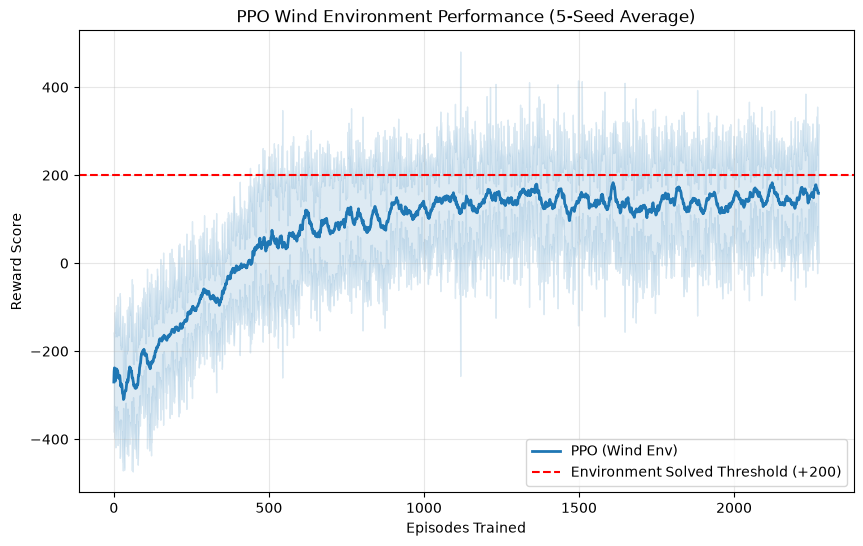

In [33]:
LOG_DIR = "./monitor_logs/wind_monitor_logs"

plt.figure(figsize=(10, 6))
all_seed_rewards = []
    
for seed in SEEDS:
    seed_path = os.path.join(LOG_DIR, f"seed_{seed}")
    try:
        df = load_results(seed_path)
        all_seed_rewards.append(df['r'].values)
    except Exception:
        print(f"Couldn't read log data for seed {seed}")
        continue

if not all_seed_rewards:
    print("No wind environment data logs found to plot.")

# Normalizing lengths across runs
min_len = min(len(run) for run in all_seed_rewards)
truncated_runs = [run[:min_len] for run in all_seed_rewards]
    
mean_rewards = np.mean(truncated_runs, axis=0)
std_rewards = np.std(truncated_runs, axis=0)
    
# Smoothing local noise using a 20-episode rolling window
smoothed_mean = pd.Series(mean_rewards).rolling(window=20, min_periods=1).mean()
episodes = np.arange(len(smoothed_mean))
    
# Plotting performance curve and variance shading
plt.plot(episodes, smoothed_mean, color="#1f77b4", linewidth=2, label="PPO (Wind Env)")
plt.fill_between(episodes, smoothed_mean - std_rewards, smoothed_mean + std_rewards, color="#1f77b4", alpha=0.15)
    
plt.axhline(y=200, color='r', linestyle='--', label='Environment Solved Threshold (+200)')
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("PPO Wind Environment Performance (5-Seed Average)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
    
output_image = "ppo_wind_curve.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Performance chart saved to '{output_image}'")
plt.show()


## Testing PPO on Wind environment

 Starting 5-Seed evaluation ...

 Seed 42 raw metrics:
Mean Reward: 156.51
Success Rate: 77.0%
Crash Rate: 11.0%

 Seed 84 raw metrics:
Mean Reward: 198.76
Success Rate: 82.0%
Crash Rate: 11.0%

 Seed 146 raw metrics:
Mean Reward: 199.39
Success Rate: 83.0%
Crash Rate: 16.0%

 Seed 1447 raw metrics:
Mean Reward: 166.41
Success Rate: 74.0%
Crash Rate: 23.0%

 Seed 2026 raw metrics:
Mean Reward: 164.71
Success Rate: 74.0%
Crash Rate: 20.0%

 Final 5-seed metrics averages(PPO - Wind Environment):
Overall Mean Reward: 177.16 +/- 18.21
Overall Success Rate: 78.0%
Overall Crash Rate: 16.2%
Plotting testing distribution plot...
Testing visualization saved as 'ppo_wind_testing_distribution.png'


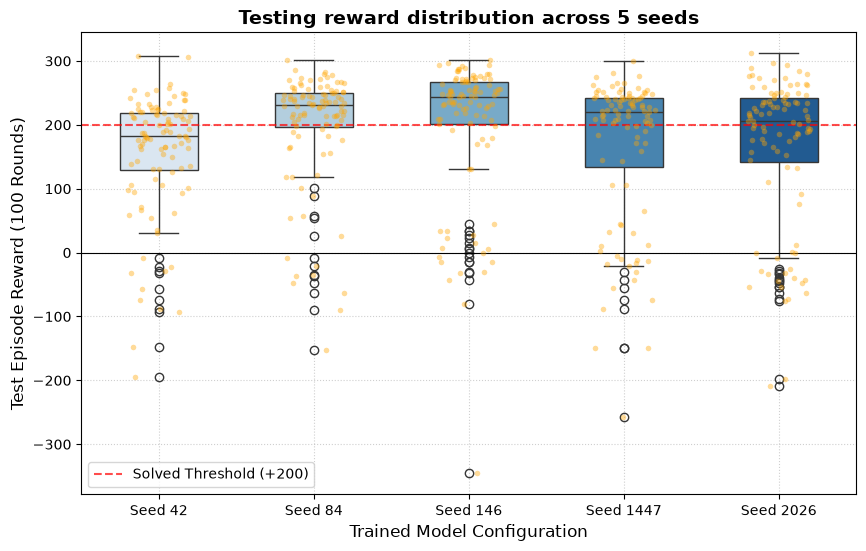

In [27]:
import seaborn as sns

NUM_EVAL_EPISODES = 100

all_seed_mean_rewards = []
all_seed_success_rates = []
all_seed_crash_rates = []

# Storing all 100 raw rewards for every single seed for plotting
all_test_rewards_data = {}

env = gym.make("LunarLander-v3", enable_wind=True, wind_power=15.0, turbulence_power=1.5)

print(" Starting 5-Seed evaluation ...\n")

for seed in SEEDS:
    model_path = f"./best_models/ppo_wind/ppo_wind_seed_{seed}/best_model.zip"
    model = PPO.load(model_path, env=env)
    
    seed_rewards = []
    successes = 0
    crashes = 0
    
    for ep in range(NUM_EVAL_EPISODES):
        obs, _ = env.reset()
        done = False
        truncated = False
        total_reward = 0
        
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward
            
            # Tracking result at the end of the episode
            if done or truncated:
                if reward >= 50:  # Safe landing
                    successes += 1
                elif reward <= -100: # crashed
                    crashes += 1
                    
        seed_rewards.append(total_reward)
    
    # Calculating metrics for current seed
    seed_mean_reward = np.mean(seed_rewards)
    seed_success_rate = (successes / NUM_EVAL_EPISODES) * 100
    seed_crash_rate = (crashes / NUM_EVAL_EPISODES) * 100
    
    all_seed_mean_rewards.append(seed_mean_reward)
    all_seed_success_rates.append(seed_success_rate)
    all_seed_crash_rates.append(seed_crash_rate)
    all_test_rewards_data[f"Seed {seed}"] = seed_rewards
    
    print(f" Seed {seed} raw metrics:")
    print(f"Mean Reward: {seed_mean_reward:.2f}")
    print(f"Success Rate: {seed_success_rate:.1f}%")
    print(f"Crash Rate: {seed_crash_rate:.1f}%\n")

env.close()

# Calculating averages across all seeds
final_reward_mean = np.mean(all_seed_mean_rewards)
final_reward_std = np.std(all_seed_mean_rewards)
final_success_mean = np.mean(all_seed_success_rates)
final_crash_mean = np.mean(all_seed_crash_rates)

print(" Final 5-seed metrics averages(PPO - Wind Environment):")
print(f"Overall Mean Reward: {final_reward_mean:.2f} +/- {final_reward_std:.2f}")
print(f"Overall Success Rate: {final_success_mean:.1f}%")
print(f"Overall Crash Rate: {final_crash_mean:.1f}%")

# Plotting and saving the distribution plot
print("Plotting testing distribution plot...")
plt.figure(figsize=(10, 6))

# Create a boxplot with individual data points overlaid
sns.boxplot(data=list(all_test_rewards_data.values()), palette="Blues", width=0.5)
sns.stripplot(data=list(all_test_rewards_data.values()), color="orange", alpha=0.4, size=4, jitter=0.2)

# Formatting the X-axis labels to match our seeds
plt.xticks(ticks=range(len(SEEDS)), labels=list(all_test_rewards_data.keys()))

# Structural thresholds
plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (+200)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Testing reward distribution across 5 seeds", fontsize=14, fontweight='bold')
plt.xlabel("Trained Model Configuration", fontsize=12)
plt.ylabel("Test Episode Reward (100 Rounds)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig("ppo_wind_testing_distribution.png", dpi=300)
print("Testing visualization saved as 'ppo_wind_testing_distribution.png'")
plt.show()

# PPO with Reward shaping environmwnt

In [14]:
# Distance Penalty Wrapper  ***************fixed
class DistancePenaltyWrapper(gym.Wrapper):
    def __init__(self, env, penalty_weight=0.1):
        super().__init__(env)
        self.penalty_weight = penalty_weight

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        x, y = obs[0], obs[1]
        distance = np.sqrt(x**2 + y**2)
        shaped_reward = reward - self.penalty_weight * distance
        info['raw_reward'] = reward  # preserve raw signal for outcome detection
        return obs, shaped_reward, terminated, truncated, info

## Training PPO with reward shaping

In [ ]:
# Using best hyperparameters configuration
BEST_PPO_PARAMS = {
    "learning_rate": 0.0009355568,
    "n_steps": 2048,
    "batch_size": 128,
    "n_epochs": 20,
    "gamma": 0.9866241116611858,
    "gae_lambda": 0.9420083608001165,
    "clip_range": 0.20571667898817245,
    "ent_coef": 0.0005444750490770728,
}

SEEDS = [42, 84, 146, 1447, 2026]
TOTAL_TIMESTEPS = 1000000  

base_log_dir = "./monitor_logs/reward_shaping_monitor_logs"
os.makedirs(base_log_dir, exist_ok=True)

print("Starting 5-Seed training for PPO on the reward shaping environment...")

for seed in SEEDS:
    print(f" Running Seed {seed}...")

    # Enabling wind and rotational turbulence (spinning the lander out of control)
    train_env = gym.make("LunarLander-v3")
    wrapped_train_env = DistancePenaltyWrapper(train_env, penalty_weight=0.1)

    eval_env = gym.make("LunarLander-v3")
    wrapped_eval_env = DistancePenaltyWrapper(eval_env, penalty_weight=0.1)

    save_dir = f"./best_models/ppo_reward_shaping/ppo_reward_shaping_seed_{seed}/"
    os.makedirs(save_dir, exist_ok=True)

    # Creating the evaluation callback
    eval_callback = EvalCallback(
        wrapped_eval_env,
        best_model_save_path=save_dir,
        log_path=save_dir,
        eval_freq=10000,         # Testing the agent every 10,000 frames
        deterministic=True,     
        render=False,
        verbose=0,
    )

    
    seed_log_path = os.path.join(base_log_dir, f"seed_{seed}")
    os.makedirs(seed_log_path, exist_ok=True)
    env = Monitor(wrapped_train_env, filename=os.path.join(seed_log_path, "monitor.csv"))
    
    model = PPO(
        "MlpPolicy",
        env,
        verbose=0,
        seed=seed,
        **BEST_PPO_PARAMS
    )
    
    model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True, callback=eval_callback)
    print(f"Training finished for Seed {seed}. Best model saved to {save_dir}best_model.zip")

    env.close()
    wrapped_eval_env.close()

Starting 5-Seed training for PPO on the reward shaping environment...

Running Seed 42...

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,001,472/1,000,000  [ 0:17:19 < 0:00:00 , 969 it/s ]

Training finished for Seed 42. Best model saved to 
./best_models/ppo_reward_shaping/ppo_reward_shaping_seed_42/best_model.zip

Running Seed 84...

...

Running Seed 2026...

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,001,472/1,000,000  [ 0:17:00 < 0:00:00 , 892 it/s ]

Training finished for Seed 2026. Best model saved to 
./best_models/ppo_reward_shaping/ppo_reward_shaping_seed_2026/best_model.zip

Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successfully exported.
Training complete. All seed log metrics have been successf

RecursionError: maximum recursion depth exceeded

Performance chart saved to 'ppo_reward_shaping_curve.png'


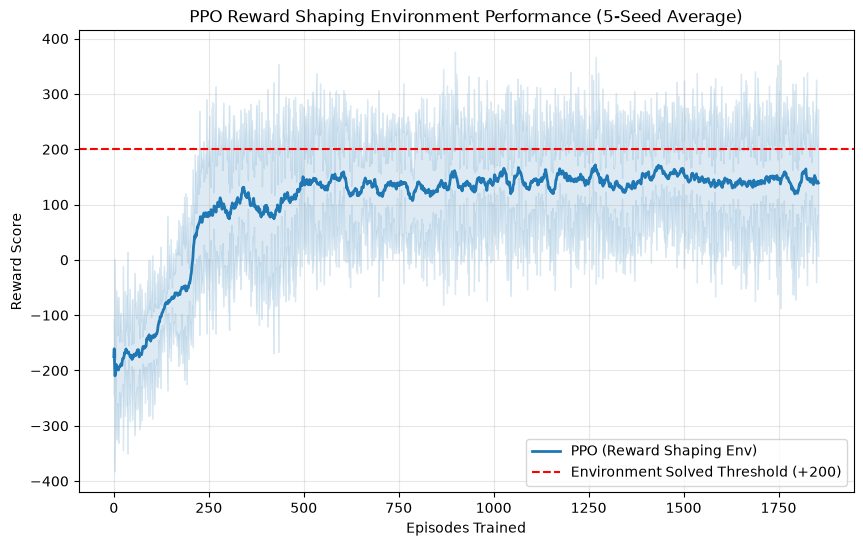

In [13]:
LOG_DIR = "./monitor_logs/reward_shaping_monitor_logs"

plt.figure(figsize=(10, 6))
all_seed_rewards = []
    
for seed in SEEDS:
    seed_path = os.path.join(LOG_DIR, f"seed_{seed}")
    try:
        df = load_results(seed_path)
        all_seed_rewards.append(df['r'].values)
    except Exception:
        print(f"Couldn't read log data for seed {seed}")
        continue

if not all_seed_rewards:
    print("No reward shaping environment data logs found to plot.")

# Normalizing lengths across runs
min_len = min(len(run) for run in all_seed_rewards)
truncated_runs = [run[:min_len] for run in all_seed_rewards]
    
mean_rewards = np.mean(truncated_runs, axis=0)
std_rewards = np.std(truncated_runs, axis=0)
    
# Smoothing local noise using a 20-episode rolling window
smoothed_mean = pd.Series(mean_rewards).rolling(window=20, min_periods=1).mean()
episodes = np.arange(len(smoothed_mean))
    
# Plotting performance curve and variance shading
plt.plot(episodes, smoothed_mean, color="#1f77b4", linewidth=2, label="PPO (Reward Shaping Env)")
plt.fill_between(episodes, smoothed_mean - std_rewards, smoothed_mean + std_rewards, color="#1f77b4", alpha=0.15)
    
plt.axhline(y=200, color='r', linestyle='--', label='Environment Solved Threshold (+200)')
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("PPO Reward Shaping Environment Performance (5-Seed Average)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
    
output_image = "ppo_reward_shaping_curve.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Performance chart saved to '{output_image}'")
plt.show()


## Testing PPO Reward shaping

 Starting 5-Seed evaluation ...

 Seed 42 raw metrics:
Mean Reward: 220.54
Success Rate: 94.0%
Crash Rate: 1.0%

 Seed 84 raw metrics:
Mean Reward: 195.84
Success Rate: 82.0%
Crash Rate: 11.0%

 Seed 146 raw metrics:
Mean Reward: 238.07
Success Rate: 97.0%
Crash Rate: 1.0%

 Seed 1447 raw metrics:
Mean Reward: 169.55
Success Rate: 96.0%
Crash Rate: 2.0%

 Seed 2026 raw metrics:
Mean Reward: 129.36
Success Rate: 76.0%
Crash Rate: 21.0%

 Final 5-seed metrics averages(PPO - Reward Shaping Environment):
Overall Mean Reward: 190.67 +/- 38.39
Overall Success Rate: 89.0%
Overall Crash Rate: 7.2%
Plotting testing distribution plot...
Testing visualization saved as 'ppo_reward_shaping_testing_distribution.png'


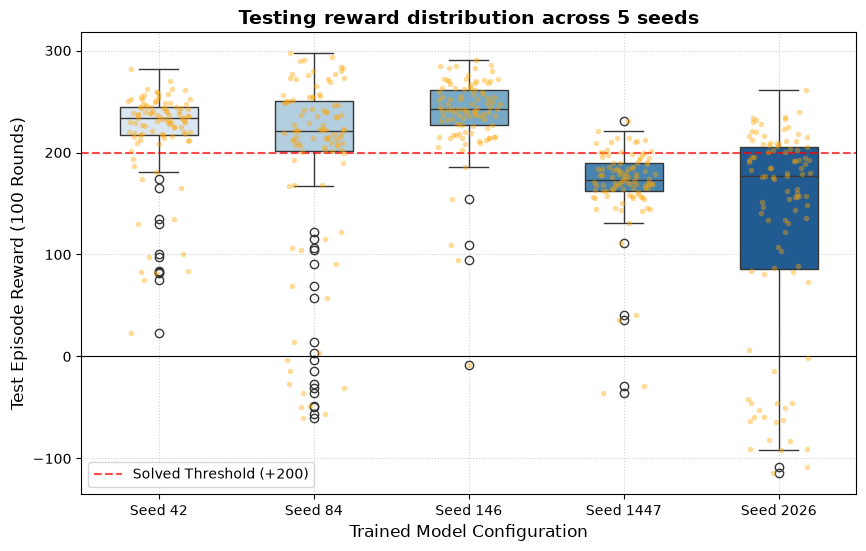

In [26]:
NUM_EVAL_EPISODES = 100

all_seed_mean_rewards = []
all_seed_success_rates = []
all_seed_crash_rates = []

# Storing all 100 raw rewards for every single seed for plotting
all_test_rewards_data = {}

env = gym.make("LunarLander-v3")
wrapped_env = DistancePenaltyWrapper(env, penalty_weight=0.1)

print(" Starting 5-Seed evaluation ...\n")

for seed in SEEDS:
    model_path = f"./best_models/ppo_reward_shaping/ppo_reward_shaping_seed_{seed}/best_model.zip"
    model = PPO.load(model_path, env=wrapped_env)
    
    seed_rewards = []
    successes = 0
    crashes = 0
    
    for ep in range(NUM_EVAL_EPISODES):
        obs, _ = wrapped_env.reset()
        done = False
        truncated = False
        total_reward = 0
        
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = wrapped_env.step(action)
            total_reward += reward
            
        # Tracking result at the end of the episode
        raw_final_reward = info.get('raw_reward', reward)
                
        if raw_final_reward >= 50:      # Safe landing (unshaped +100 bonus)
            successes += 1
        elif raw_final_reward <= -100:   # Crashed (unshaped -100 penalty)
            crashes += 1
                    
        seed_rewards.append(total_reward)
    
    # Calculating metrics for current seed
    seed_mean_reward = np.mean(seed_rewards)
    seed_success_rate = (successes / NUM_EVAL_EPISODES) * 100
    seed_crash_rate = (crashes / NUM_EVAL_EPISODES) * 100
    
    all_seed_mean_rewards.append(seed_mean_reward)
    all_seed_success_rates.append(seed_success_rate)
    all_seed_crash_rates.append(seed_crash_rate)
    all_test_rewards_data[f"Seed {seed}"] = seed_rewards
    
    print(f" Seed {seed} raw metrics:")
    print(f"Mean Reward: {seed_mean_reward:.2f}")
    print(f"Success Rate: {seed_success_rate:.1f}%")
    print(f"Crash Rate: {seed_crash_rate:.1f}%\n")

env.close()

# Calculating averages across all seeds
final_reward_mean = np.mean(all_seed_mean_rewards)
final_reward_std = np.std(all_seed_mean_rewards)
final_success_mean = np.mean(all_seed_success_rates)
final_crash_mean = np.mean(all_seed_crash_rates)

print(" Final 5-seed metrics averages(PPO - Reward Shaping Environment):")
print(f"Overall Mean Reward: {final_reward_mean:.2f} +/- {final_reward_std:.2f}")
print(f"Overall Success Rate: {final_success_mean:.1f}%")
print(f"Overall Crash Rate: {final_crash_mean:.1f}%")

# Plotting and saving the distribution plot
print("Plotting testing distribution plot...")
plt.figure(figsize=(10, 6))

# Create a boxplot with individual data points overlaid
sns.boxplot(data=list(all_test_rewards_data.values()), palette="Blues", width=0.5)
sns.stripplot(data=list(all_test_rewards_data.values()), color="orange", alpha=0.4, size=4, jitter=0.2)

# Formatting the X-axis labels to match our seeds
plt.xticks(ticks=range(len(SEEDS)), labels=list(all_test_rewards_data.keys()))

# Structural thresholds
plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (+200)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Testing reward distribution across 5 seeds", fontsize=14, fontweight='bold')
plt.xlabel("Trained Model Configuration", fontsize=12)
plt.ylabel("Test Episode Reward (100 Rounds)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig("ppo_reward_shaping_testing_distribution.png", dpi=300)
print("Testing visualization saved as 'ppo_reward_shaping_testing_distribution.png'")
plt.show()

# PPO with wind + reward shaping

## Training ppo wind + reward shaping

In [ ]:
# Using best hyperparameters configuration
BEST_PPO_PARAMS = {
    "learning_rate": 0.0009355568,
    "n_steps": 2048,
    "batch_size": 128,
    "n_epochs": 20,
    "gamma": 0.9866241116611858,
    "gae_lambda": 0.9420083608001165,
    "clip_range": 0.20571667898817245,
    "ent_coef": 0.0005444750490770728,
}

SEEDS = [42, 84, 146, 1447, 2026]
TOTAL_TIMESTEPS = 1000000  

base_log_dir = "./monitor_logs/reward_wind_shaping_monitor_logs"
os.makedirs(base_log_dir, exist_ok=True)

print("Starting 5-Seed training for PPO on the reward and wind shaping environment...")

for seed in SEEDS:
    print(f" Running Seed {seed}...")

    # Enabling wind and rotational turbulence (spinning the lander out of control)
    train_env = gym.make("LunarLander-v3", enable_wind=True, wind_power=15.0, turbulence_power=1.5)
    wrapped_train_env = DistancePenaltyWrapper(train_env, penalty_weight=0.1)

    eval_env = gym.make("LunarLander-v3", enable_wind=True, wind_power=15.0, turbulence_power=1.5)
    wrapped_eval_env = DistancePenaltyWrapper(eval_env, penalty_weight=0.1)

    save_dir = f"./best_models/ppo_reward_wind_shaping/ppo_reward_wind_shaping_seed_{seed}/"
    os.makedirs(save_dir, exist_ok=True)

    # Creating the evaluation callback
    eval_callback = EvalCallback(
        wrapped_eval_env,
        best_model_save_path=save_dir,
        log_path=save_dir,
        eval_freq=10000,         # Testing the agent every 10,000 frames
        deterministic=True,     
        render=False,
        verbose=0,
    )

    
    seed_log_path = os.path.join(base_log_dir, f"seed_{seed}")
    os.makedirs(seed_log_path, exist_ok=True)
    env = Monitor(wrapped_train_env, filename=os.path.join(seed_log_path, "monitor.csv"))
    
    model = PPO(
        "MlpPolicy",
        env,
        verbose=0,
        seed=seed,
        **BEST_PPO_PARAMS
    )
    
    model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True, callback=eval_callback)
    print(f"Training finished for Seed {seed}. Best model saved to {save_dir}best_model.zip")

    env.close()
    wrapped_eval_env.close()
    
print("\nTraining complete. All seed log metrics have been successfully exported.")

Starting 5-Seed training for PPO on the reward and wind shaping environment...

Running Seed 42...

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,001,472/1,000,000  [ 0:15:03 < 0:00:00 , 1,075 it/s ]

Training finished for Seed 42. Best model saved to 
./best_models/ppo_reward_wind_shaping/ppo_reward_wind_shaping_seed_42/best_model.zip

Running Seed 84...

...

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,001,472/1,000,000  [ 0:15:56 < 0:00:00 , 1,117 it/s ]

Training finished for Seed 1447. Best model saved to 
./best_models/ppo_reward_wind_shaping/ppo_reward_wind_shaping_seed_1447/best_model.zip

Running Seed 2026...

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,001,472/1,000,000  [ 0:15:51 < 0:00:00 , 1,061 it/s ]

Training finished for Seed 2026. Best model saved to 
./best_models/ppo_reward_wind_shaping/ppo_reward_wind_shaping_seed_2026/best_model.zip

Performance chart saved to 'ppo_reward_shaping_wind_curve.png'


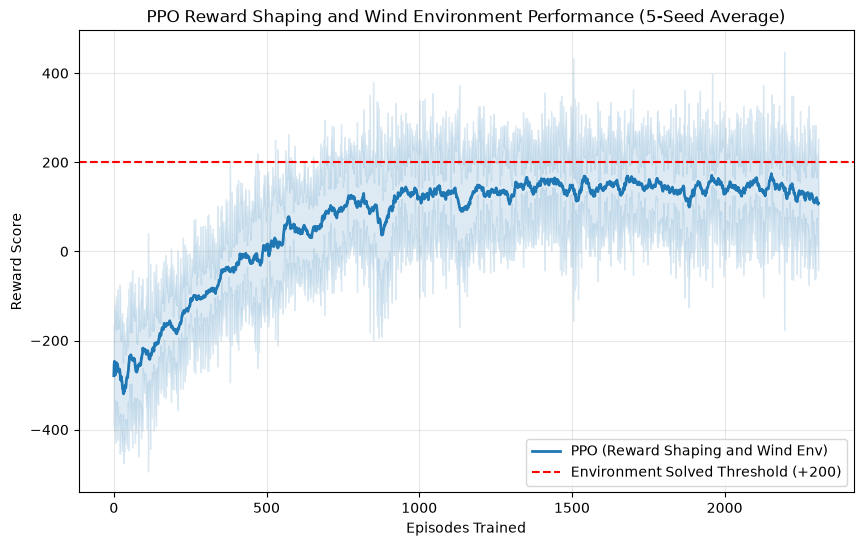

In [5]:
LOG_DIR = "./monitor_logs/reward_wind_shaping_monitor_logs"

plt.figure(figsize=(10, 6))
all_seed_rewards = []
    
for seed in SEEDS:
    seed_path = os.path.join(LOG_DIR, f"seed_{seed}")
    try:
        df = load_results(seed_path)
        all_seed_rewards.append(df['r'].values)
    except Exception:
        print(f"Couldn't read log data for seed {seed}")
        continue

if not all_seed_rewards:
    print("No reward shaping and wind environment data logs found to plot.")

# Normalizing lengths across runs
min_len = min(len(run) for run in all_seed_rewards)
truncated_runs = [run[:min_len] for run in all_seed_rewards]
    
mean_rewards = np.mean(truncated_runs, axis=0)
std_rewards = np.std(truncated_runs, axis=0)
    
# Smoothing local noise using a 20-episode rolling window
smoothed_mean = pd.Series(mean_rewards).rolling(window=20, min_periods=1).mean()
episodes = np.arange(len(smoothed_mean))
    
# Plotting performance curve and variance shading
plt.plot(episodes, smoothed_mean, color="#1f77b4", linewidth=2, label="PPO (Reward Shaping and Wind Env)")
plt.fill_between(episodes, smoothed_mean - std_rewards, smoothed_mean + std_rewards, color="#1f77b4", alpha=0.15)
    
plt.axhline(y=200, color='r', linestyle='--', label='Environment Solved Threshold (+200)')
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("PPO Reward Shaping and Wind Environment Performance (5-Seed Average)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
    
output_image = "ppo_reward_shaping_wind_curve.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Performance chart saved to '{output_image}'")
plt.show()


## Testing PPO wind + reward shaping

 Starting 5-Seed evaluation ...

 Seed 42 raw metrics:
Mean Reward: 158.61
Success Rate: 80.0%
Crash Rate: 8.0%

 Seed 84 raw metrics:
Mean Reward: 159.50
Success Rate: 81.0%
Crash Rate: 15.0%

 Seed 146 raw metrics:
Mean Reward: 190.76
Success Rate: 83.0%
Crash Rate: 8.0%

 Seed 1447 raw metrics:
Mean Reward: 151.92
Success Rate: 79.0%
Crash Rate: 13.0%

 Seed 2026 raw metrics:
Mean Reward: 192.35
Success Rate: 86.0%
Crash Rate: 11.0%

 Final 5-seed metrics averages(PPO - Wind and Reward Shaping Environment):
Overall Mean Reward: 170.63 +/- 17.30
Overall Success Rate: 81.8%
Overall Crash Rate: 11.0%
Plotting testing distribution plot...
Testing visualization saved as 'ppo_reward_wind_shaping_testing_distribution.png'


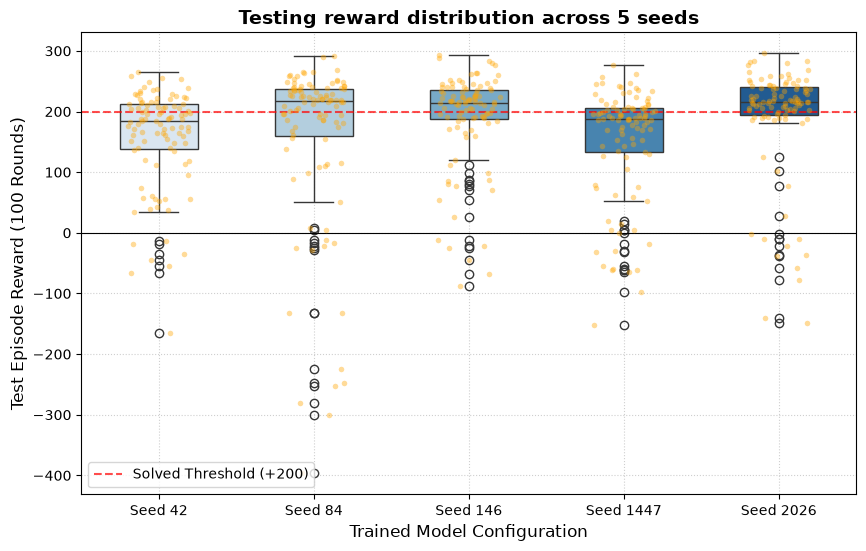

In [28]:
NUM_EVAL_EPISODES = 100

all_seed_mean_rewards = []
all_seed_success_rates = []
all_seed_crash_rates = []

# Storing all 100 raw rewards for every single seed for plotting
all_test_rewards_data = {}

# Applying both wind and reward shaping for evaluation
env = gym.make("LunarLander-v3", enable_wind=True, wind_power=15.0, turbulence_power=1.5)
wrapped_env = DistancePenaltyWrapper(env, penalty_weight=0.1)

print(" Starting 5-Seed evaluation ...\n")

for seed in SEEDS:
    model_path = f"./best_models/ppo_reward_wind_shaping/ppo_reward_wind_shaping_seed_{seed}/best_model.zip"
    model = PPO.load(model_path, env=wrapped_env)
    
    seed_rewards = []
    successes = 0
    crashes = 0
    
    for ep in range(NUM_EVAL_EPISODES):
        obs, _ = wrapped_env.reset()
        done = False
        truncated = False
        total_reward = 0
        
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = wrapped_env.step(action)
            total_reward += reward
            
        # Tracking result at the end of the episode
        raw_final_reward = info.get('raw_reward', reward)
                
        if raw_final_reward >= 50:      # Safe landing (unshaped +100 bonus)
            successes += 1
        elif raw_final_reward <= -100:   # Crashed (unshaped -100 penalty)
            crashes += 1
                    
        seed_rewards.append(total_reward)
    
    # Calculating metrics for current seed
    seed_mean_reward = np.mean(seed_rewards)
    seed_success_rate = (successes / NUM_EVAL_EPISODES) * 100
    seed_crash_rate = (crashes / NUM_EVAL_EPISODES) * 100
    
    all_seed_mean_rewards.append(seed_mean_reward)
    all_seed_success_rates.append(seed_success_rate)
    all_seed_crash_rates.append(seed_crash_rate)
    all_test_rewards_data[f"Seed {seed}"] = seed_rewards
    
    print(f" Seed {seed} raw metrics:")
    print(f"Mean Reward: {seed_mean_reward:.2f}")
    print(f"Success Rate: {seed_success_rate:.1f}%")
    print(f"Crash Rate: {seed_crash_rate:.1f}%\n")

env.close()

# Calculating averages across all seeds
final_reward_mean = np.mean(all_seed_mean_rewards)
final_reward_std = np.std(all_seed_mean_rewards)
final_success_mean = np.mean(all_seed_success_rates)
final_crash_mean = np.mean(all_seed_crash_rates)

print(" Final 5-seed metrics averages(PPO - Wind and Reward Shaping Environment):")
print(f"Overall Mean Reward: {final_reward_mean:.2f} +/- {final_reward_std:.2f}")
print(f"Overall Success Rate: {final_success_mean:.1f}%")
print(f"Overall Crash Rate: {final_crash_mean:.1f}%")

# Plotting and saving the distribution plot
print("Plotting testing distribution plot...")
plt.figure(figsize=(10, 6))

# Create a boxplot with individual data points overlaid
sns.boxplot(data=list(all_test_rewards_data.values()), palette="Blues", width=0.5)
sns.stripplot(data=list(all_test_rewards_data.values()), color="orange", alpha=0.4, size=4, jitter=0.2)

# Formatting the X-axis labels to match our seeds
plt.xticks(ticks=range(len(SEEDS)), labels=list(all_test_rewards_data.keys()))

# Structural thresholds
plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (+200)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Testing reward distribution across 5 seeds", fontsize=14, fontweight='bold')
plt.xlabel("Trained Model Configuration", fontsize=12)
plt.ylabel("Test Episode Reward (100 Rounds)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig("ppo_reward_wind_shaping_testing_distribution.png", dpi=300)
print("Testing visualization saved as 'ppo_reward_wind_shaping_testing_distribution.png'")
plt.show()